In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as skcl
import sklearn.preprocessing as skpp
import sklearn.ensemble as ske

In [2]:
df = pd.read_csv('/content/zomato dataset.csv', encoding='latin1')

In [3]:
df_code=pd.read_excel('/content/Country-Code.xlsx')

In [4]:
df=pd.merge(df,df_code,on='Country Code')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


# **Data Cleaning**

In [5]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [6]:
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,No,No,No,No,3,4.1,Green,Very Good,788,Turkey
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,No,No,No,No,3,4.2,Green,Very Good,1034,Turkey
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,No,No,No,No,4,3.7,Yellow,Good,661,Turkey
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,No,No,No,No,4,4.0,Green,Very Good,901,Turkey
9550,5927402,Walter's Coffee Roastery,208,ÛÁstanbul,"CafeaÛôa Mahallesi, BademaltÛ± Sokak, No 21/B,...",Moda,"Moda, ÛÁstanbul",29.026016,40.984776,Cafe,...,No,No,No,No,2,4.0,Green,Very Good,591,Turkey


In [7]:
df.shape

(9551, 22)

In [8]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [10]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [11]:
df.dropna(subset=['Cuisines'], inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

<Axes: ylabel='Votes'>

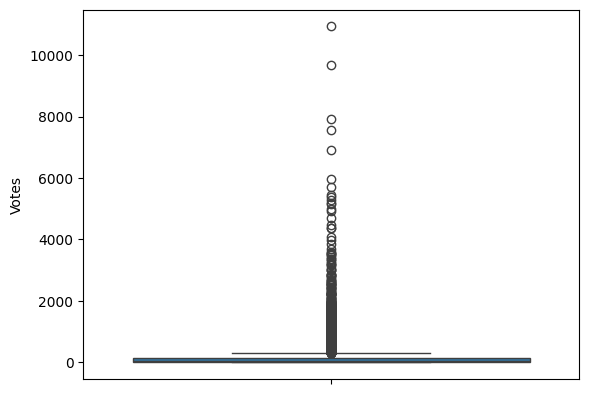

In [13]:
sns.boxplot(df['Votes'])

<Axes: ylabel='Average Cost for two'>

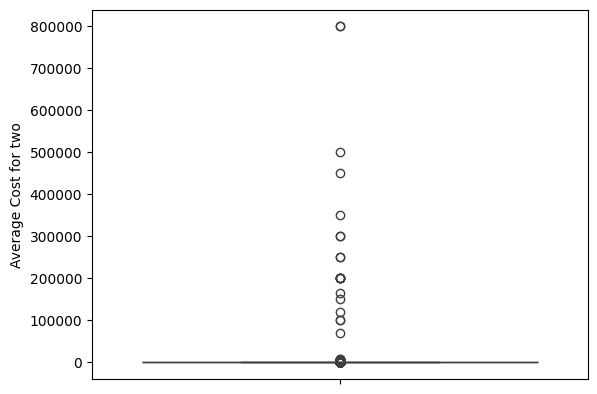

In [14]:
sns.boxplot(df['Average Cost for two'])

Remove ouliers from average cost of two

In [15]:
Q1 = df['Average Cost for two'].quantile(0.25)
Q3 = df['Average Cost for two'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

df = df[(df['Average Cost for two'] >= lower_limit) &
        (df['Average Cost for two'] <= upper_limit)]

Remove outliers from Votes

In [16]:
Q1 = df['Votes'].quantile(0.25)
Q3 = df['Votes'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

df = df[(df['Votes'] >= lower_limit) &
        (df['Votes'] <= upper_limit)]

In [17]:
print(df.shape)

(7679, 22)


# **Data Manipulation ( Feature Engineering )**

In [18]:
# Create Ratinng Colummn (converting average rating into category)
def create_rating_category(rating):
  if rating <= 2.0:
    return "Poor"
  elif rating > 2.0 and rating <= 3.0:
    return "Average"
  elif rating > 3.0 and rating <= 4.0:
    return "Good"
  else:
    return "Excellent"

df['Rating_Category'] = df['Aggregate rating'].apply(create_rating_category)

In [19]:
df['Average Cost'] = df['Average Cost for two']//2

In [20]:
# creating category for average cost
def cost_category(cost):
  if cost <= 300:
    return "Budget"
  elif cost > 300 and cost<=700 :
    return " Moderate"
  elif cost >700 and cost <=1200:
    return "High"
  else:
    return "Expensive"
df['Cost_category'] = df['Average Cost'].apply(cost_category)

In [21]:
df['Popularity Score'] = df['Votes']*df['Aggregate rating' ]

# **Visualization**

**1. Top 3 food ordering Countries**

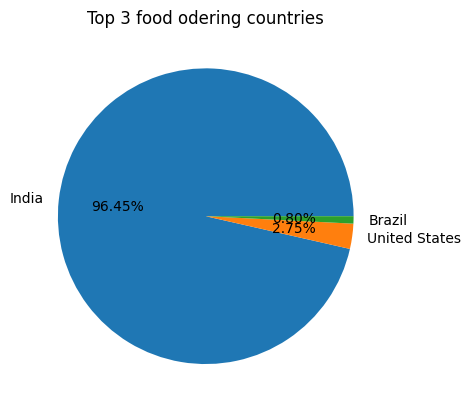

In [22]:
country_count = df['Country'].value_counts()
plt.pie(country_count.head(3),autopct='%0.2f%%',labels=country_count.index[:3])
plt.title('Top 3 food odering countries')
plt.show()

India dominates the dataset with the highest number of restaurants

Followed by the USA and the UK, indicating Zomato's primary market is India.

**2. Distribution of Rating**

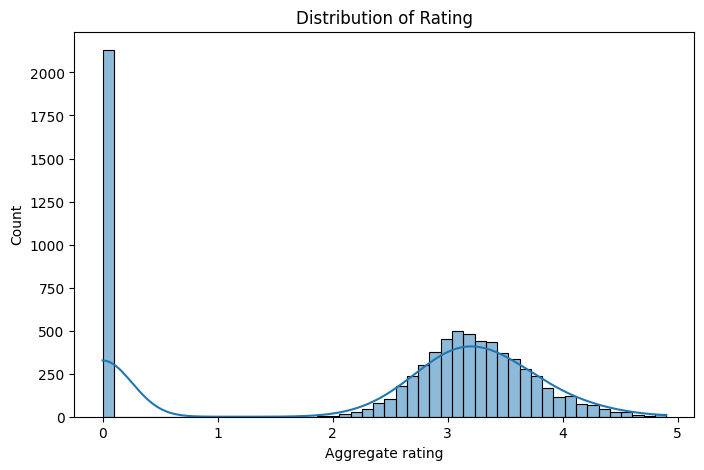

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=50, kde=True)
plt.title("Distribution of Rating")
plt.show()

Most restaurants have ratings between 2.5 and 4.5

Indicating that the majority receive average to good customer feedback.

**3. Top Countries by Number of Restraunts**

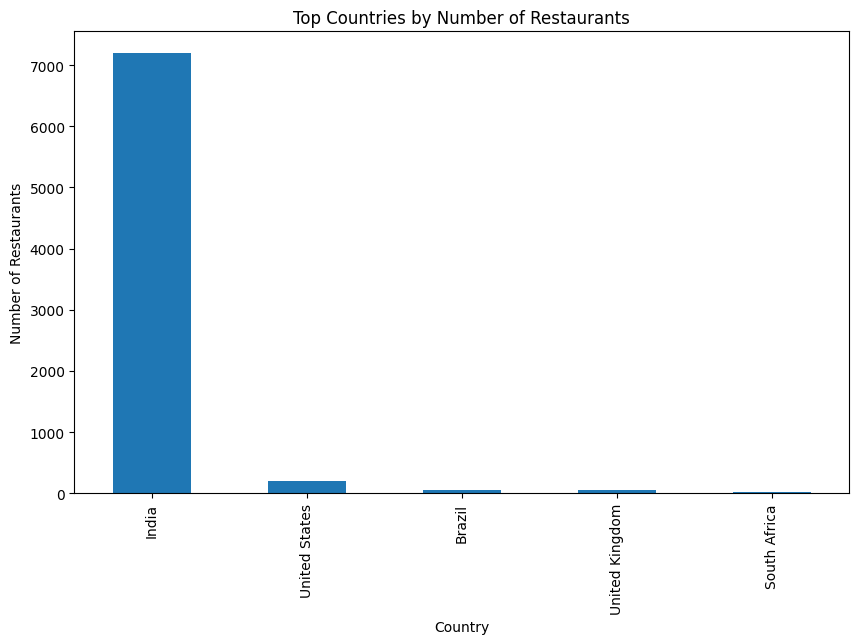

In [24]:
country_count = df['Country'].value_counts()

plt.figure(figsize=(10,6))
country_count.head(5).plot(kind='bar')
plt.xlabel("Country")
plt.ylabel("Number of Restaurants")
plt.title("Top Countries by Number of Restaurants")
plt.show()

**4. Top Cities**

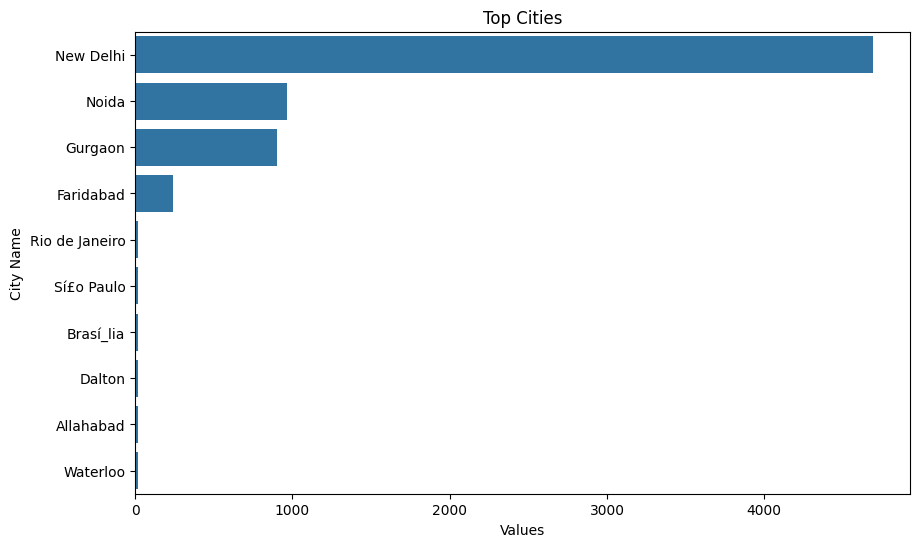

In [25]:
city_count = df['City'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=city_count.values, y=city_count.index)
plt.ylabel("City Name")
plt.xlabel("Values")
plt.title("Top Cities")
plt.show()


**5. Top Cuisines**

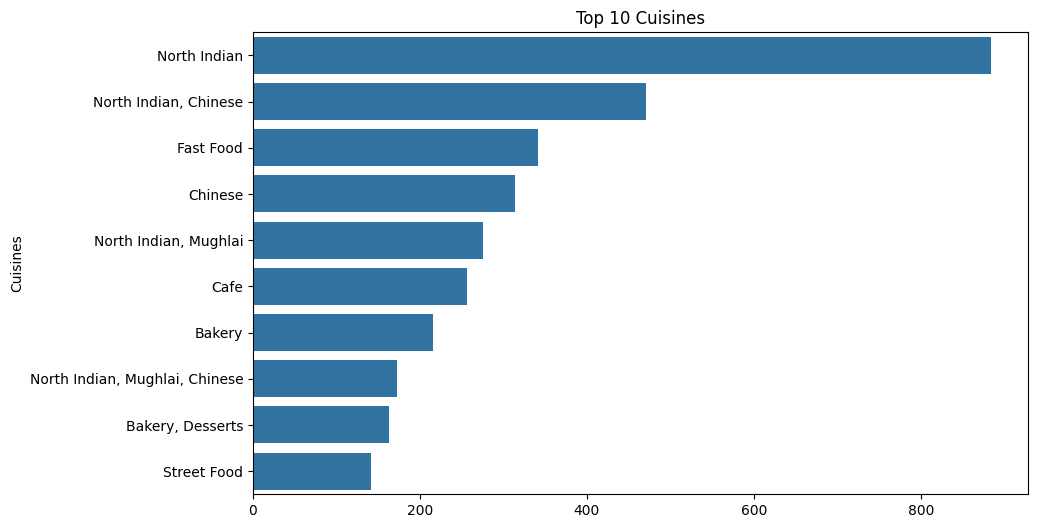

In [26]:
cuisines_count = df['Cuisines'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x= cuisines_count.values, y=cuisines_count.index)
plt.title("Top 10 Cuisines")
plt.show()

**6. Votes vs Rating relationship**

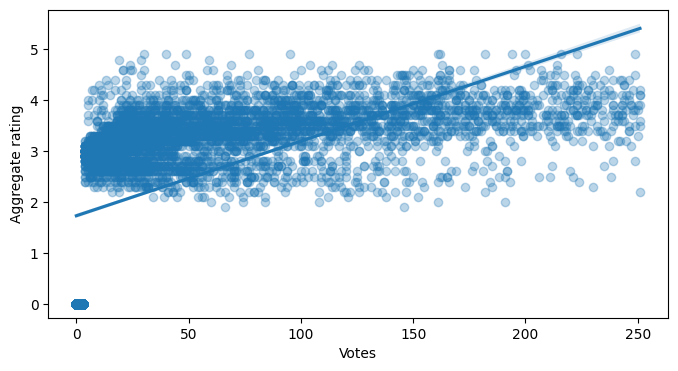

In [27]:
plt.figure(figsize=(8,4))
sns.regplot(
    x= 'Votes',
    y='Aggregate rating',
    data = df,
    scatter_kws={'alpha':0.3}
)
plt.show()

**7. Average Reciept cost in their currencies**

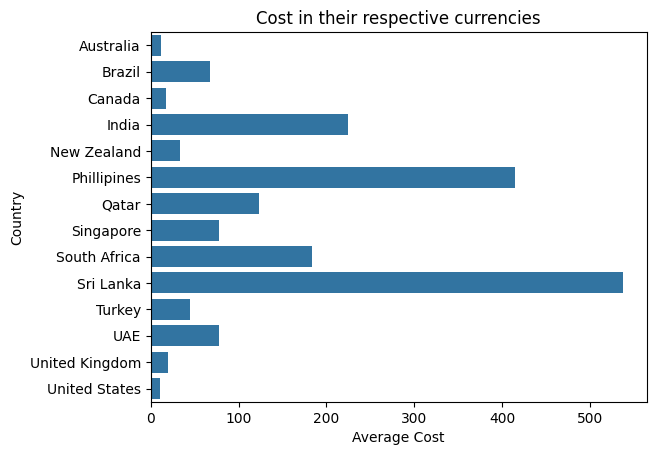

In [28]:
df=df[df['Average Cost']<25000]
vt=df.groupby('Country')[["Average Cost"]].mean().reset_index()

sns.barplot(data=vt,x="Average Cost",y='Country')
plt.title('Cost in their respective currencies')
plt.show()

**8. Top 10 cusines order in India**

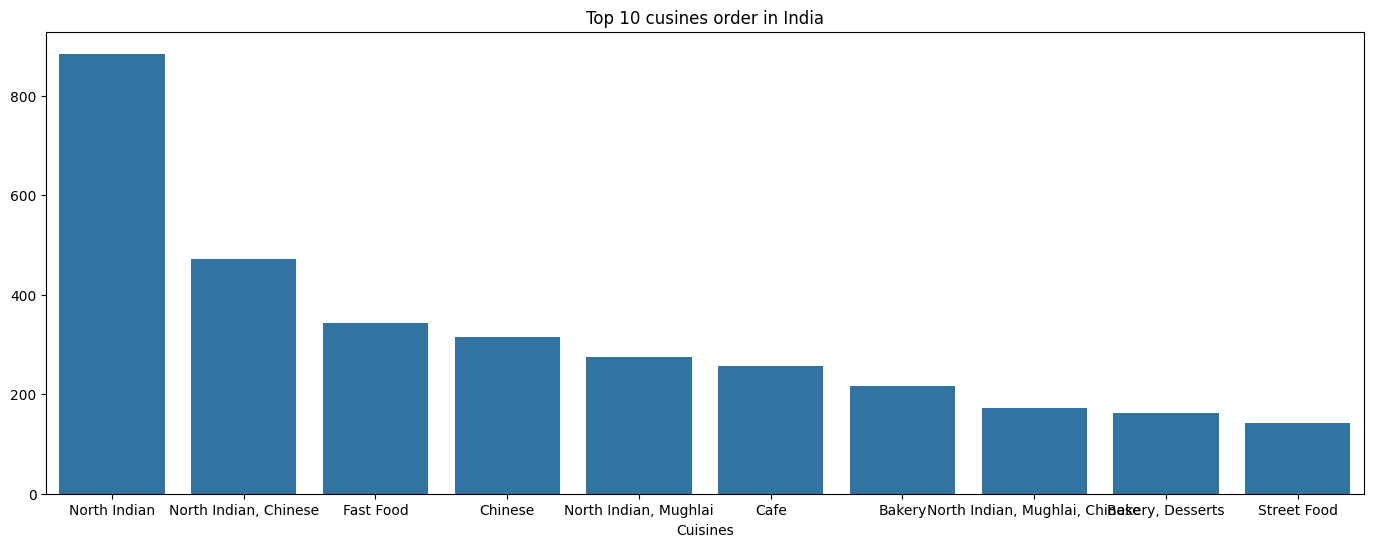

In [29]:
df.groupby('Cuisines')['Country'].value_counts()
cuisines_count = df['Cuisines'].value_counts().head(10)
plt.figure(figsize=(17,6))
sns.barplot(x=cuisines_count.index, y=cuisines_count.values)
plt.title('Top 10 cusines order in India')
plt.show()


**9. Ratings on the zomato**

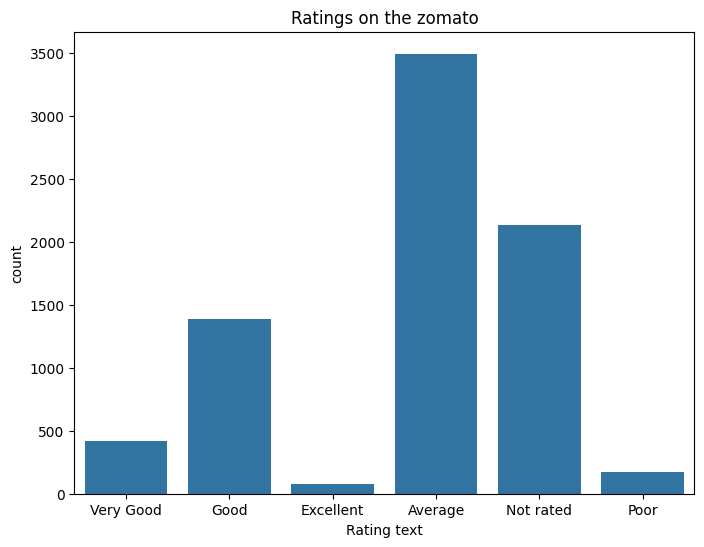

In [30]:
plt.figure(figsize=(8,6))
sns.countplot(x='Rating text', data =df)
plt.title('Ratings on the zomato')
plt.show()


**10. Ratings colour across the zomato**

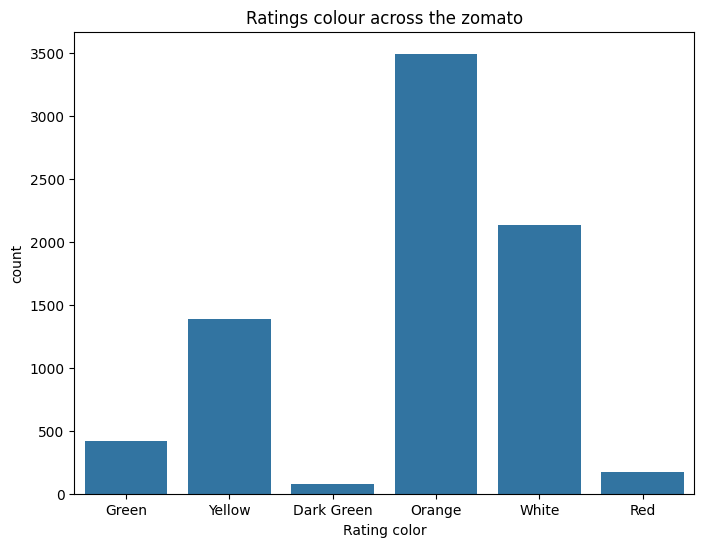

In [31]:
plt.figure(figsize=(8,6))
sns.countplot(x = 'Rating color', data =  df)
plt.title('Ratings colour across the zomato')
plt.show()

**11. Most food ordered city in India**

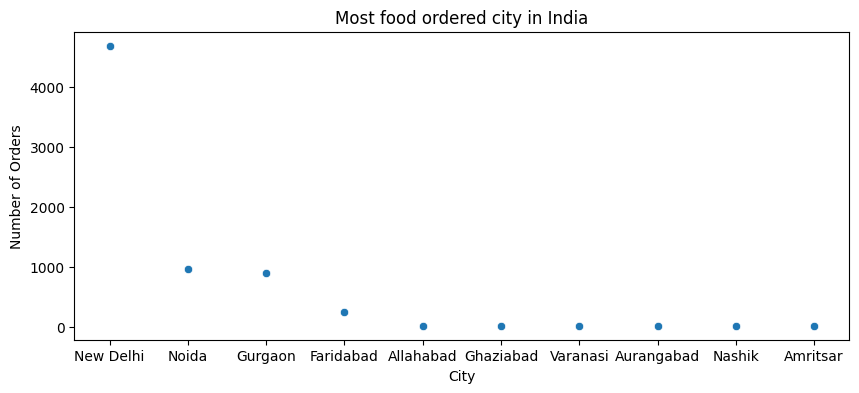

In [32]:
india_df = df[df['Country Code'] == 1]
count_city = india_df['City'].value_counts().head(10)
plt.figure(figsize=(10,4))
sns.scatterplot(x=count_city.index , y=count_city.values)
plt.title('Most food ordered city in India')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.show()

**12. Country wise average rating**

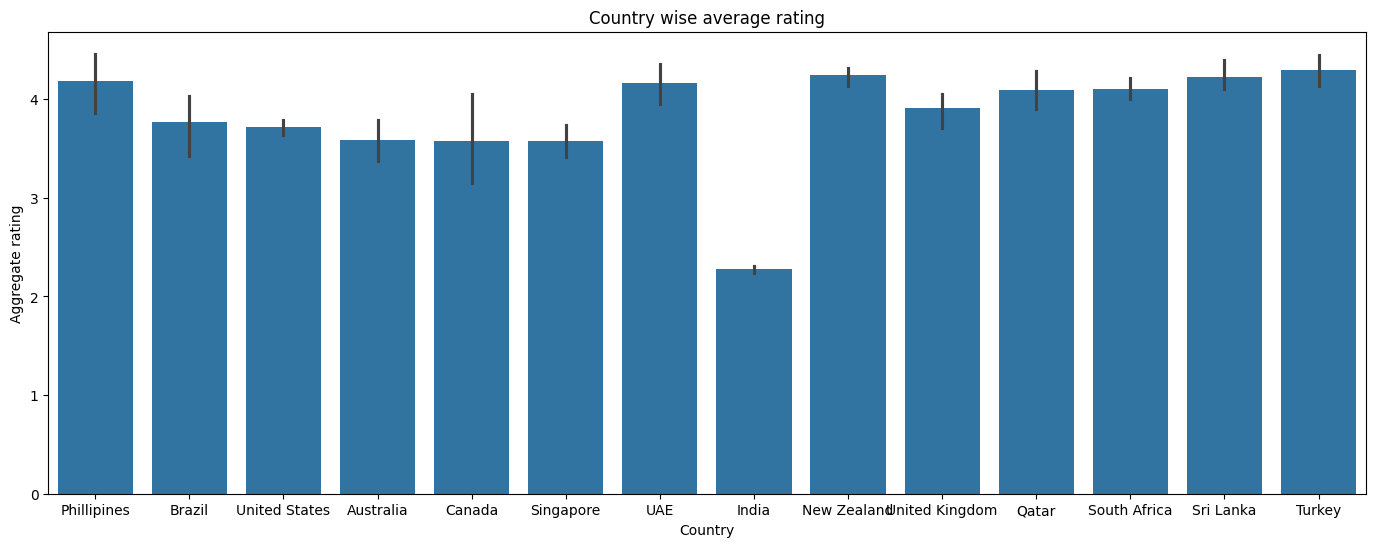

In [33]:
plt.figure(figsize=(17,6))
sns.barplot(x='Country',y='Aggregate rating' , data =df)
plt.title('Country wise average rating')
plt.show()

**13. Correlation Heatmap**

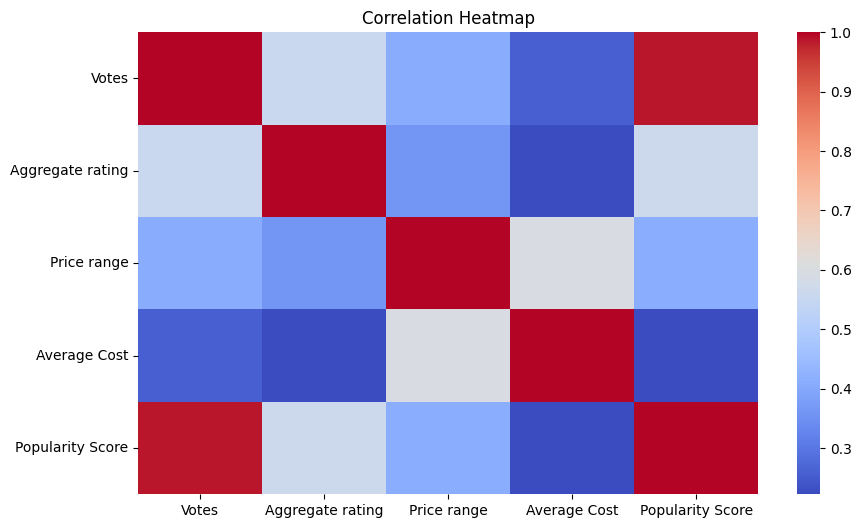

In [34]:
numeric_df = df[['Votes','Aggregate rating','Price range','Average Cost','Popularity Score']]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# **Important Findings**


India orders the most food through Zomato followed by US and UK

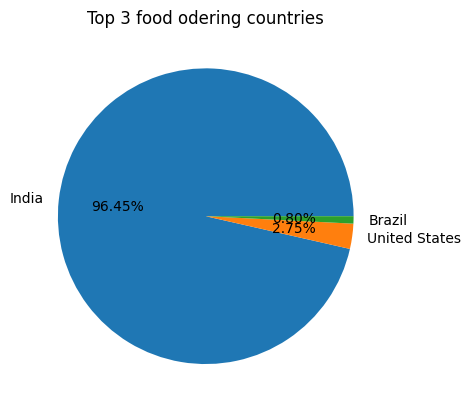

In [35]:
country_count = df['Country'].value_counts()
plt.pie(country_count.head(3),autopct='%0.2f%%',labels=country_count.index[:3])
plt.title('Top 3 food odering countries')
plt.show()

Average food rating is between 2.7 to 4.0

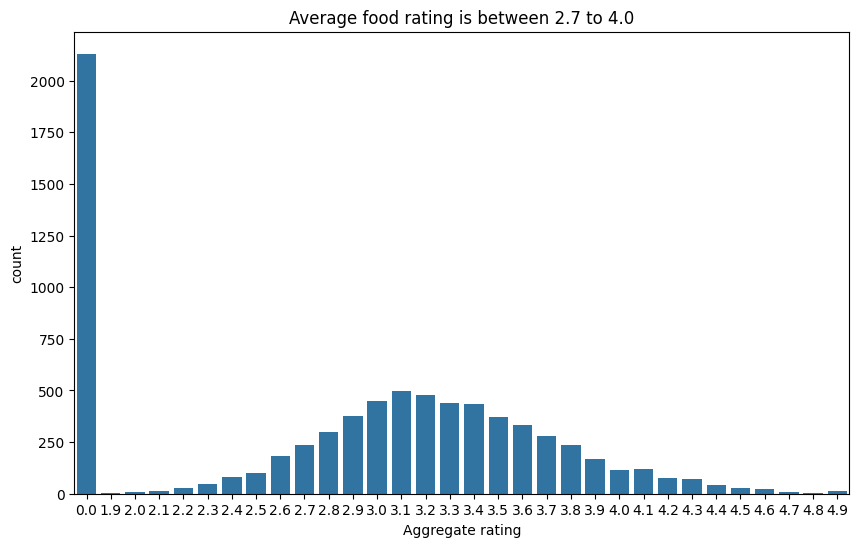

In [36]:
plt.figure(figsize=(10,6))
sns.countplot(x='Aggregate rating', data = df)
plt.title('Average food rating is between 2.7 to 4.0')
plt.show()


Top 10 cuisines over the zomato

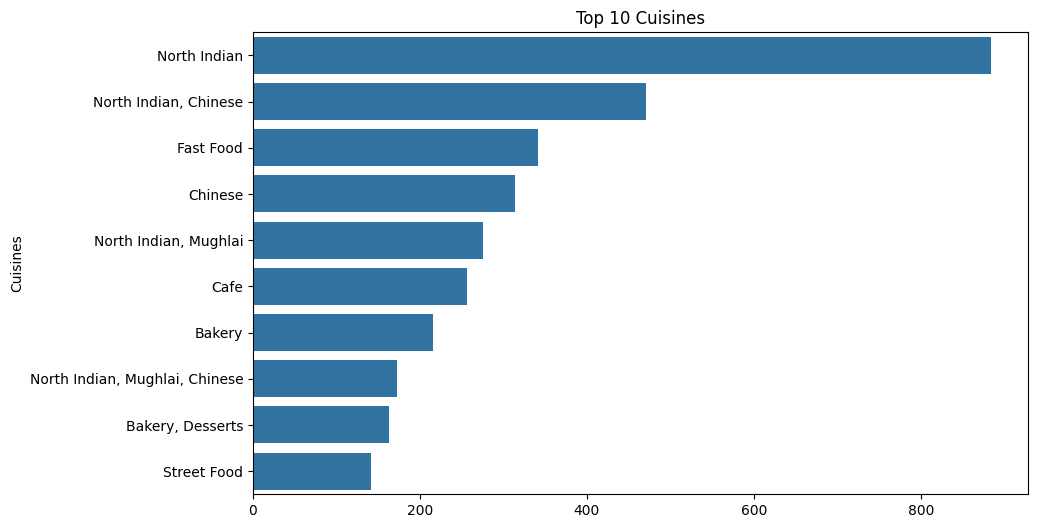

In [37]:
cuisines_count = df['Cuisines'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x= cuisines_count.values, y=cuisines_count.index)
plt.title("Top 10 Cuisines")
plt.show()


Top 10 food ordering cities

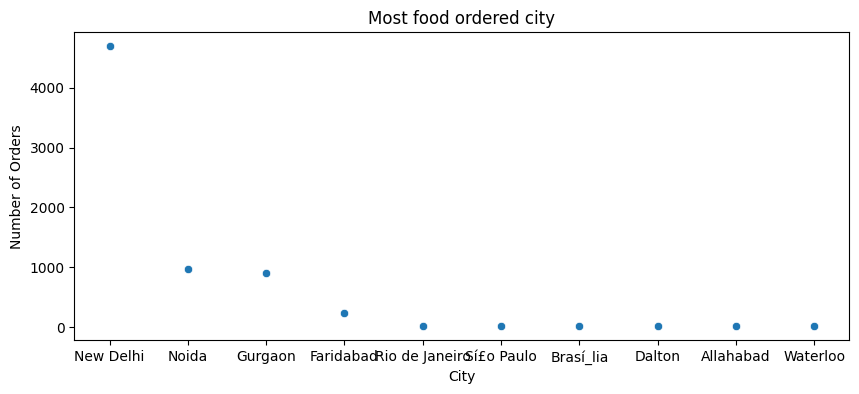

In [38]:
count_city = df['City'].value_counts().head(10)
plt.figure(figsize=(10,4))
sns.scatterplot(x=count_city.index , y=count_city.values)
plt.title('Most food ordered city')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.show()

Average cost for 2 around the world

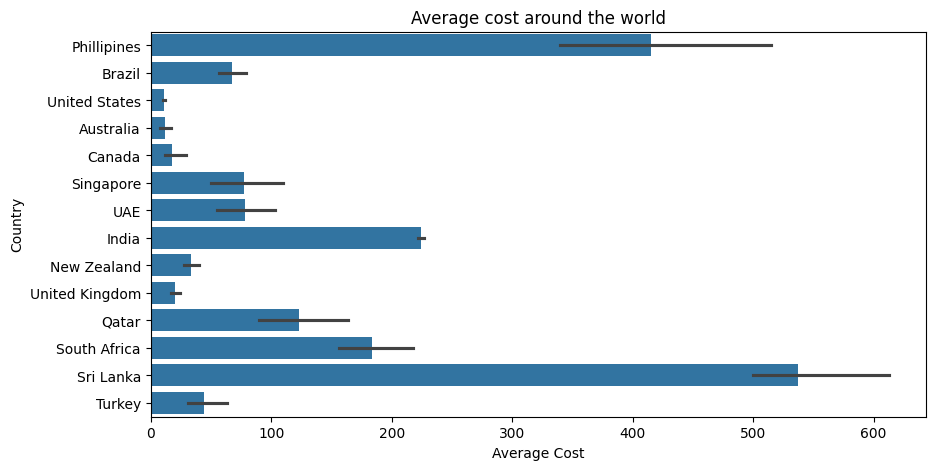

In [39]:
plt.figure(figsize=(10,5))
sns.barplot(x='Average Cost', y='Country', data  = df)
plt.title('Average cost around the world')
plt.show()

Online food ordering possible or not

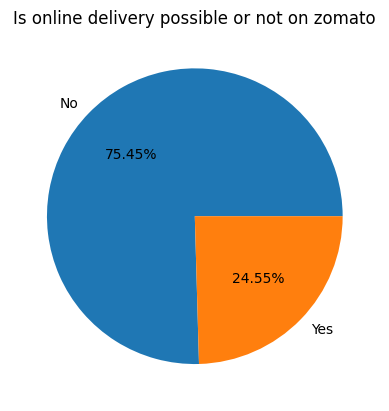

In [40]:
count_online = df['Has Online delivery'].value_counts()
plt.pie(count_online,autopct='%0.2f%%',labels=count_online.index)
plt.title('Is online delivery possible or not on zomato')
plt.show()

Top 10 restaurants by popularity score

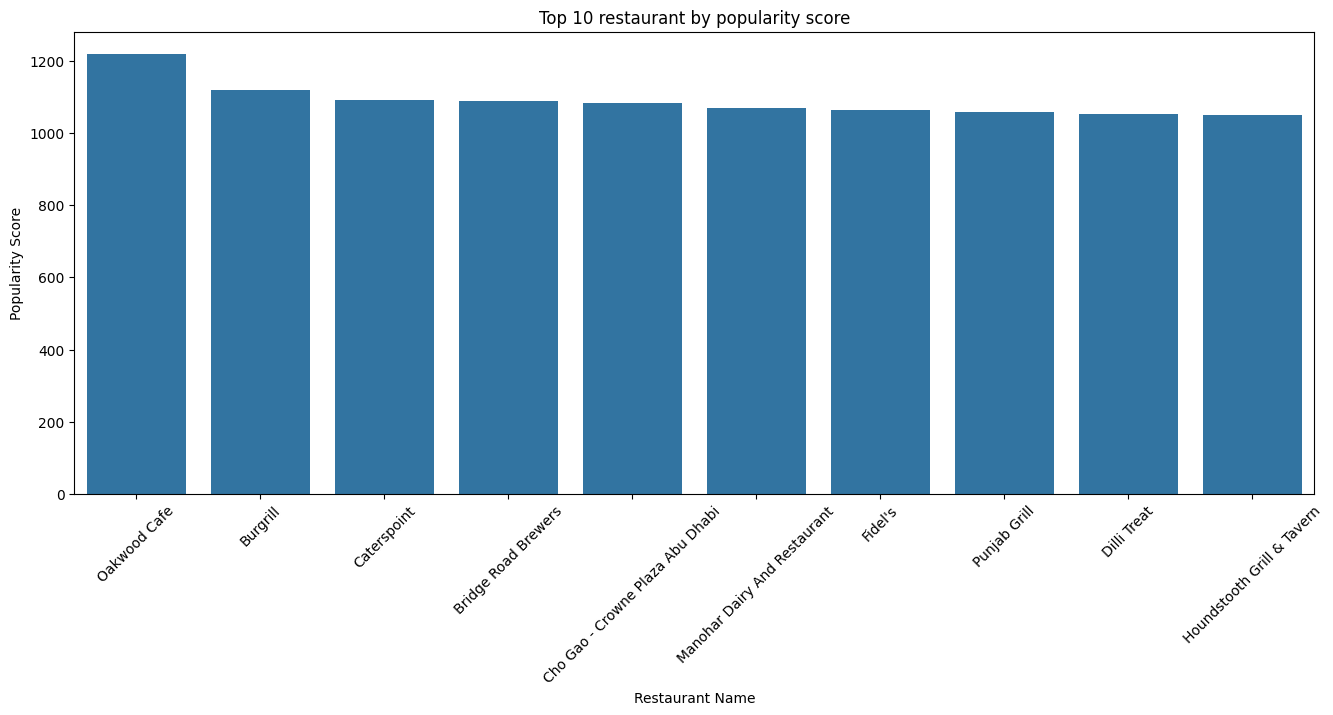

In [41]:
top_rest= df.sort_values('Popularity Score' ,ascending=False).head(10)
plt.figure(figsize=(16,6))
sns.barplot(x='Restaurant Name', y='Popularity Score',data = top_rest)
plt.title('Top 10 restaurant by popularity score')
plt.xticks(rotation=45)
plt.show()

>> indian contributes a major no. in online food ordering

In [42]:
df.to_csv('zomato_analysis_project.csv',index=False)

In [43]:
from google.colab import files
files.download('zomato_analysis_project.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>